# Exploratory Data Analysis (EDA)

This notebook presents an exploratory analysis of the IT asset dataset. The objective is to identify potential cost drivers, assess operational risks, and screen candidate features for future predictive modeling through visualization and descriptive statistics.

## 1. Setup & Data Loading
In this step, the cleaned dataset produced by the ETL pipeline is loaded. I initialize the visualization environment to ensure consistent styling across all charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Load the processed dataset
df = pd.read_csv('../data/processed_it_assets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Asset_ID                 1000 non-null   object 
 1   Asset_Type               1000 non-null   object 
 2   Status                   1000 non-null   object 
 3   Department               1000 non-null   object 
 4   Assigned_To              763 non-null    object 
 5   Acquisition_Date         1000 non-null   object 
 6   Asset_Age                1000 non-null   float64
 7   Warranty_Expiry_Date     1000 non-null   object 
 8   Days_to_Warranty_Expiry  1000 non-null   int64  
 9   Warranty_Status          1000 non-null   object 
 10  License_Expiry_Date      780 non-null    object 
 11  Maintenance_Cost         1000 non-null   float64
 12  Repair_Count             1000 non-null   int64  
 13  Repair_Intensity         1000 non-null   float64
 14  Is_High_Cost             

## 2. Data Quality Check

Before performing analysis, we examine missing values and duplicated records to ensure data reliability.

In [4]:
df.isna().sum().sort_values(ascending=False)
df.duplicated().sum()

0

## 3. Data Preparation

To improve analysis efficiency and consistency:
- Categorical variables are converted to appropriate data types
- Date columns are parsed into datetime format

In [5]:
# Convert date columns and categories
date_cols = ['Acquisition_Date', 'Warranty_Expiry_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

cat_cols = ['Asset_Type', 'Department', 'Status', 'Vendor_Name', 'Warranty_Status', 'Compliance_Status']
for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Asset_ID                 1000 non-null   object        
 1   Asset_Type               1000 non-null   category      
 2   Status                   1000 non-null   category      
 3   Department               1000 non-null   category      
 4   Assigned_To              763 non-null    object        
 5   Acquisition_Date         1000 non-null   datetime64[ns]
 6   Asset_Age                1000 non-null   float64       
 7   Warranty_Expiry_Date     1000 non-null   datetime64[ns]
 8   Days_to_Warranty_Expiry  1000 non-null   int64         
 9   Warranty_Status          1000 non-null   category      
 10  License_Expiry_Date      780 non-null    object        
 11  Maintenance_Cost         1000 non-null   float64       
 12  Repair_Count             1000 non-n

In [6]:
df.head()

,Asset_ID,Asset_Type,Status,Department,Assigned_To,Acquisition_Date,Asset_Age,Warranty_Expiry_Date,Days_to_Warranty_Expiry,Warranty_Status,License_Expiry_Date,Maintenance_Cost,Repair_Count,Repair_Intensity,Is_High_Cost,Vendor_Name,Location,Compliance_Status,OS_Version
0,ASSET_0001,Laptop,In Use,Finance,User_066,2025-10-29,0.5,2028-10-29,922,Active,2028-02-29,2994.97,0,0.00,1,Dell,Other,Compliant,Windows 11
1,ASSET_0002,Monitor,In Use,IT,User_228,2020-12-20,5.3,2024-06-20,-670,Expired,NaN,401.83,3,0.57,0,Lenovo,Hsinchu,Non-Compliant,Not Applicable
2,ASSET_0003,Server,Stock,R&D,NaN,2023-09-04,2.6,2028-09-04,867,Active,2027-07-04,247.42,3,1.15,0,Dell,Other,At Risk,VMware ESXi
3,ASSET_0004,Tablet,In Use,Sales,User_327,2024-02-25,2.2,2026-08-25,126,Active,2025-05-25,164.24,2,0.91,0,Apple,Other,Compliant,iPadOS 18
4,ASSET_0005,Server,In Use,R&D,User_263,2023-04-04,3.0,2027-04-04,348,Active,2026-08-04,1749.18,2,0.67,1,Dell,Cloud,Compliant,Ubuntu 22.04


## 4. Inventory Profiling & Cost Overview
Before diving into specific relationships, I perform an initial inspection of the data distribution. This helps identify the scale of the inventory across different departments and asset types.

**Key Focus:** Understanding the "Shape" of the IT infrastructure.

Asset Inventory Summary
Asset_Type
Laptop     319
Desktop    197
Tablet     172
Monitor    157
Server     155
Name: Asset_ID, dtype: int64


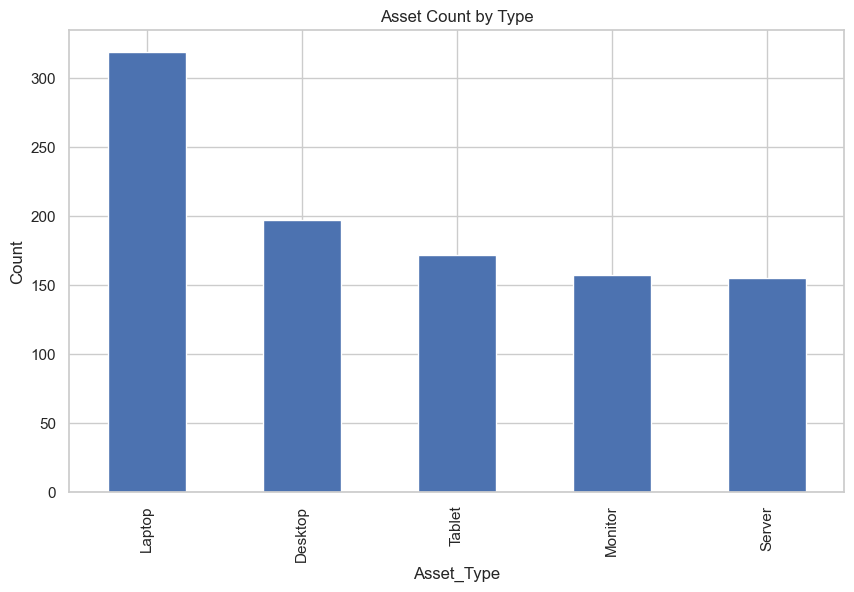


Maintenance Cost by Risk Level
                   count        sum         mean   median
Compliance_Status                                        
Non-Compliant        347  615911.21  1774.960259  1055.82
Compliant            451  134434.27   298.080421   172.11
At Risk              202  132903.95   657.940347   373.08


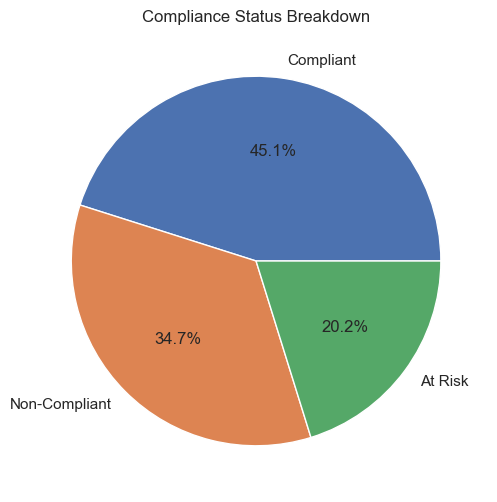

In [7]:
# Aggregation Analysis

# Count assets by type
asset_summary = df.groupby('Asset_Type', observed=False)['Asset_ID'].count().sort_values(ascending=False)
print("Asset Inventory Summary")
print(asset_summary)

# Bar chart of asset types
df['Asset_Type'].value_counts().plot(kind='bar')
plt.title('Asset Count by Type')
plt.ylabel('Count')
plt.show()

# Maintenance cost summary by compliance status
risk_summary = df.groupby('Compliance_Status', observed=False)['Maintenance_Cost'].agg(
    ['count', 'sum', 'mean', 'median']
).sort_values('sum', ascending=False)
print("\nMaintenance Cost by Risk Level")
print(risk_summary)

# Pie Chart for Compliance_Status
df['Compliance_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Compliance Status Breakdown')
plt.ylabel('')
plt.show()


In [8]:
# High Risk Action List
# Assets that are 'Non-Compliant' and warranty expires within 90 days
high_risk_list = df[
    (df['Compliance_Status'] == 'Non-Compliant') &
    (df['Days_to_Warranty_Expiry'].between(0, 90))
]

print("High Risk Assets to Replace: ", len(high_risk_list))
high_risk_list[['Asset_ID', 'Asset_Type', 'Days_to_Warranty_Expiry', 'Maintenance_Cost']].head()

High Risk Assets to Replace:  11


,Asset_ID,Asset_Type,Days_to_Warranty_Expiry,Maintenance_Cost
53,ASSET_0054,Laptop,42,366.12
124,ASSET_0125,Server,85,1573.11
179,ASSET_0180,Laptop,74,446.85
216,ASSET_0217,Server,28,2325.70
234,ASSET_0235,Laptop,65,332.85


## 5. Cost Structure Analysis
This heatmap crosses **Department** with **Asset Type** to identify specific "High-Cost Centers." By visualizing the sum of maintenance costs, I can pinpoint which departments and equipment categories are consuming the majority of the IT budget.

> **Observation**: This visualization helps justify department-specific budget allocations and identifies areas where hardware refresh cycles may need to be accelerated.

/var/folders/g6/ypqsg6fx0cv23h420cpm0r7w0000gn/T/ipykernel_64387/48036291.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index='Department',


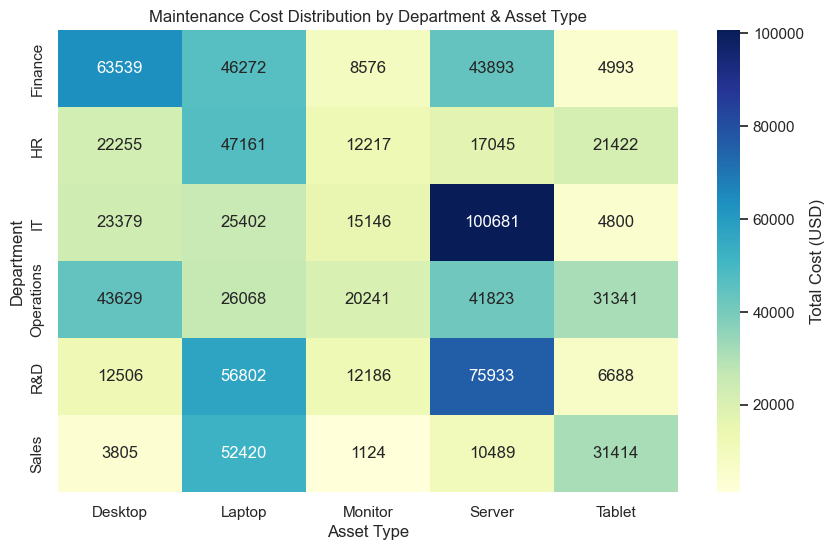

In [9]:
pivot_table = df.pivot_table(index='Department', 
                             columns='Asset_Type', 
                             values='Maintenance_Cost', 
                             aggfunc='sum').fillna(0)

sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Total Cost (USD)'})

plt.title('Maintenance Cost Distribution by Department & Asset Type')
plt.xlabel('Asset Type')
plt.ylabel('Department')
plt.show()

Note: This visualization reflects total maintenance burden and may be influenced by the number of assets in each category.

## 6. Relationship Exploration & Risk Patterns
In this section, I investigate the statistical relationships between numerical variables such as Asset Age, Repair Count, and Maintenance Cost. This validates my hypothesis that aging hardware increases financial risk.

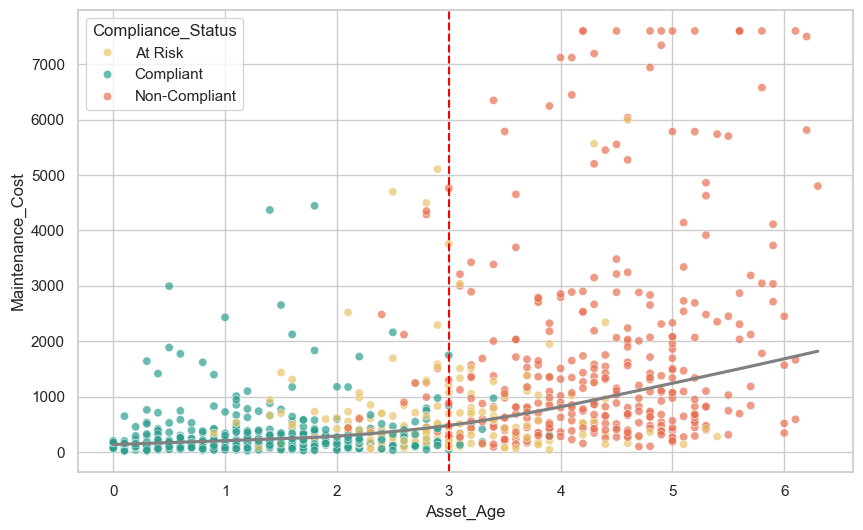

In [10]:
# Cost Analysis: Age & Risk
# Scatter plot: Asset Age vs. Maintenance Cost
sns.scatterplot(
    data=df,
    x='Asset_Age',
    y='Maintenance_Cost',
    hue='Compliance_Status',
    palette={
        'Compliant': '#2a9d8f',      
        'At Risk': '#e9c46a',     
        'Non-Compliant': '#e76f51'
    },
    alpha=0.7
)

sns.regplot(
    data=df,
    x='Asset_Age',
    y='Maintenance_Cost',
    scatter=False,
    lowess=True,
    color='gray'
)

plt.axvline(x=3, color='red', linestyle='--', label='Suggested Refresh Point (3 yrs)')

In [11]:
# Maintenance Cost by Risk Level (Groupby)
risk_summary = df.groupby('Compliance_Status')['Maintenance_Cost'].agg(['count','sum','mean','median']).sort_values('sum', ascending=False)
risk_summary.columns = ['Count', 'Total_Cost', 'Avg_Cost', 'Median_Cost']

total_inventory = risk_summary['Count'].sum()
total_budget = risk_summary['Total_Cost'].sum()

risk_summary['Count_Share (%)'] = (risk_summary['Count'] / total_inventory * 100).round(1)
risk_summary['Cost_Share (%)'] = (risk_summary['Total_Cost'] / total_budget * 100).round(1)

risk_summary[['Count', 'Count_Share (%)', 'Total_Cost', 'Cost_Share (%)', 'Avg_Cost', 'Median_Cost']]

/var/folders/g6/ypqsg6fx0cv23h420cpm0r7w0000gn/T/ipykernel_64387/2019206497.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = df.groupby('Compliance_Status')['Maintenance_Cost'].agg(['count','sum','mean','median']).sort_values('sum', ascending=False)


,Count,Count_Share (%),Total_Cost,Cost_Share (%),Avg_Cost,Median_Cost
Compliance_Status,,,,,,
Non-Compliant,347,34.7,615911.21,69.7,1774.960259,1055.82
Compliant,451,45.1,134434.27,15.2,298.080421,172.11
At Risk,202,20.2,132903.95,15.0,657.940347,373.08


In [12]:
corr_val = df[['Repair_Count', 'Maintenance_Cost']].corr().iloc[0,1]
print(corr_val)

0.4721947759149943


Repair count shows a strong positive association with maintenance cost, indicating that failure frequency is a key driver of overall expense.

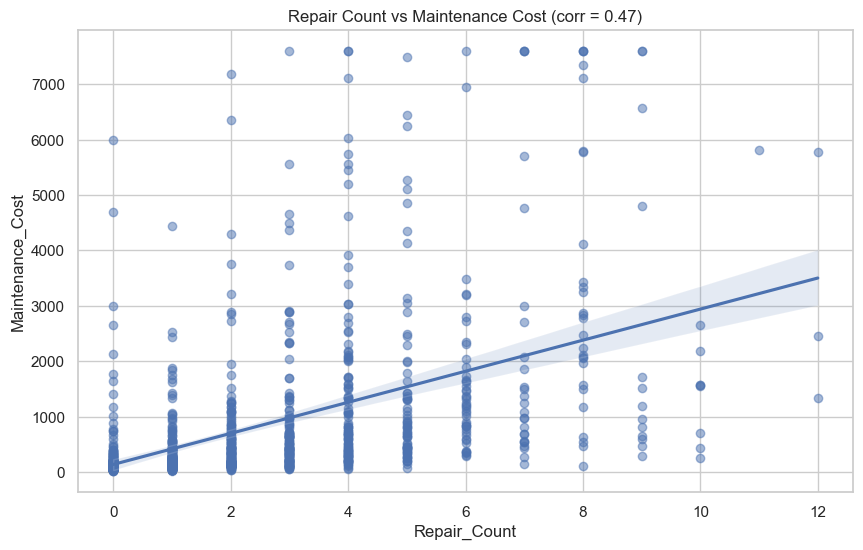

In [13]:
sns.regplot(data=df, x='Repair_Count', y='Maintenance_Cost', scatter_kws={'alpha':0.5})
plt.title(f'Repair Count vs Maintenance Cost (corr = {corr_val:.2f})')
plt.show()

Based on the scatter plot and the summary table, we can conclude:

* As equipment gets older, maintenance costs generally increase and become more unstable
* Non-compliant assets tend to be associated with higher maintenance costs
* At-risk assets show intermediate behavior
* Compliant assets generally cluster at lower cost levels

👉 In simple terms:
**Older equipment + poor maintenance = higher costs, with a risk of sudden spikes**

## 7. Operational Risk & Strategic Action

**Rule-Based High Risk Filter**

In addition to predictive modeling, a simple operational alert rule is used to identify assets requiring immediate attention.

Assets are flagged as high risk if they are:
- Non-compliant
- Within 90 days of warranty expiry

This rule-based filter complements the machine learning model by capturing urgent cases that already meet clear business risk conditions.

In [14]:
# High Risk Filter: Non-Compliant & Near Expiry
high_risk_assets = df[
    (df['Compliance_Status'] == 'Non-Compliant') &
    (df['Days_to_Warranty_Expiry'].between(0, 90))
]

print("High Risk Assets Needing Immediate Attention:", len(high_risk_assets))
if len(high_risk_assets) > 0:
    display(high_risk_assets[['Asset_ID', 'Asset_Type', 'Days_to_Warranty_Expiry', 'Maintenance_Cost']].head(10))
else:
    print("✅ No critical risks identified within the 90-day window.")

High Risk Assets Needing Immediate Attention: 11


,Asset_ID,Asset_Type,Days_to_Warranty_Expiry,Maintenance_Cost
53,ASSET_0054,Laptop,42,366.12
124,ASSET_0125,Server,85,1573.11
179,ASSET_0180,Laptop,74,446.85
216,ASSET_0217,Server,28,2325.70
234,ASSET_0235,Laptop,65,332.85
273,ASSET_0274,Server,81,1361.06
491,ASSET_0492,Server,80,1421.94
534,ASSET_0535,Desktop,19,815.96
562,ASSET_0563,Server,43,1357.36
772,ASSET_0773,Laptop,67,298.20


/var/folders/g6/ypqsg6fx0cv23h420cpm0r7w0000gn/T/ipykernel_64387/1419280003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_High_Cost', y='Asset_Age', data=df, palette="viridis")


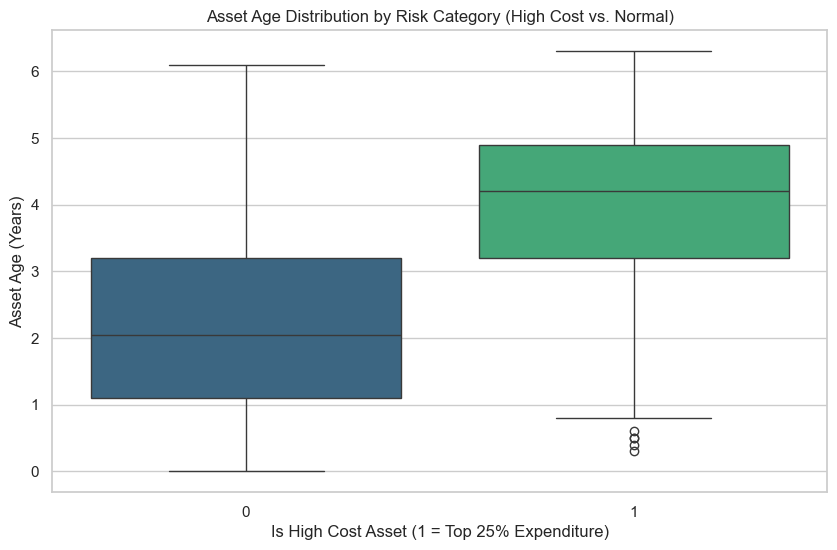

Percentage of High-Cost Assets by Department:
Department
IT            0.339869
R&D           0.310345
Operations    0.262032
Finance       0.248521
HR            0.192308
Sales         0.164634
Name: Is_High_Cost, dtype: float64

Feature Correlation Matrix (Target: Maintenance_Cost):
Maintenance_Cost    1.000000
Asset_Age           0.478421
Repair_Count        0.472195
Repair_Intensity    0.027904
Name: Maintenance_Cost, dtype: float64


In [15]:
# Validate Target Variable Distribution
# Check if the 25/75 split is visually significant across asset ages
sns.boxplot(x='Is_High_Cost', y='Asset_Age', data=df, palette="viridis")
plt.title('Asset Age Distribution by Risk Category (High Cost vs. Normal)')
plt.xlabel('Is High Cost Asset (1 = Top 25% Expenditure)')
plt.ylabel('Asset Age (Years)')
plt.show()

# Departmental Risk Density
# Identify which departments are carrying the highest ratio of high-maintenance assets
dept_risk_ratio = df.groupby('Department', observed=False)['Is_High_Cost'].mean().sort_values(ascending=False)
print("Percentage of High-Cost Assets by Department:")
print(dept_risk_ratio)

# Correlation Matrix Snippet
# Confirming that Repair_Count and Asset_Age act as strong predictors for Maintenance_Cost
correlations = df[['Maintenance_Cost', 'Repair_Count', 'Asset_Age', 'Repair_Intensity']].corr()
print("\nFeature Correlation Matrix (Target: Maintenance_Cost):")
print(correlations['Maintenance_Cost'].sort_values(ascending=False))

**Key Insight:**

Both Asset_Age (0.48) and Repair_Count (0.47) show moderate-to-strong positive correlations with maintenance expenditure. This dual-driver pattern confirms that aging hardware and high failure frequency are the two most reliable predictors for financial risk.

**Departmental Risk Analysis:**

- **Finding:** High-intensity departments like IT (33.9%) and R&D (31.0%) have nearly double the risk of high-maintenance costs compared to Sales (16.4%).

- **Strategic Takeaway:** IT budget optimization should prioritize hardware refreshes for technical roles first, as their equipment reaches "High Cost" status significantly faster than administrative roles.

## EDA Final Summary

- **Financial Strategy:**
The scatter plot shows a positive relationship between asset age and maintenance cost. As assets age, maintenance costs tend to increase and become more variable, indicating a higher risk of unexpected repair expenses. This suggests the importance of establishing a structured hardware refresh cycle (e.g., around 3–4 years) to better control long-term costs.

- **Risk Mitigation:**
Non-compliant assets represent the largest share of the inventory in this dataset and contribute significantly to total maintenance costs. This indicates that compliance status plays a critical role in cost control, and addressing non-compliant assets can significantly reduce overall IT maintenance expenses.

- **Action Plan:**
Assets classified as “Non-Compliant” and “At Risk” should be prioritized in future procurement and maintenance planning. By focusing on these higher-risk assets, organizations can shift from reactive repairs to a more proactive and preventive maintenance strategy.

## Feature Selection for Future Modeling

**Goal:** To predict whether an asset is likely to fall into a high-risk or high-cost category, depending on the availability of suitable outcome labels.

Selected features include:
- **Asset_Age (Primary Driver)**

- **Repair_Count (Frequency Indicator)**

- **Repair_Intensity (Stress Indicator - New)**

- **Warranty_Status**

- **Compliance_Status (Risk Indicator)**